**Road Accident Dataset EDA (Exploratory Data Analysis)**


# Q1. Load Dataset and Display First 10 Rows

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import seaborn as sns

df = pd.read_csv("QP_Data_road_accident_dataset_with_missing.xlsx - QP_Data_road_accident_dataset_w.csv")

# First 10 rows
print(df.head(10))

  Country  Year     Month Day of Week Time of Day Urban/Rural  Road Type  \
0     USA  2002   October     Tuesday     Evening       Rural     Street   
1      UK  2014  December    Saturday     Evening       Urban     Street   
2     USA  2012      July      Sunday   Afternoon       Urban    Highway   
3      UK  2017       May    Saturday     Evening       Urban  Main Road   
4  Canada  2002      July     Tuesday   Afternoon       Rural    Highway   
5   India  2010       May      Monday     Evening       Urban     Street   
6   China  2010     March      Monday   Afternoon       Rural     Street   
7     USA  2016      July      Friday   Afternoon       Rural  Main Road   
8   Japan  2014    August    Thursday   Afternoon       Rural    Highway   
9     USA  2007     April      Monday     Evening       Urban    Highway   

  Weather Conditions  Visibility Level  Number of Vehicles Involved  ...  \
0              Windy               NaN                            1  ...   
1          

### numerical and categorical variables

In [3]:

num_cols = df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['Year', 'Visibility Level', 'Number of Vehicles Involved',
       'Speed Limit', 'Driver Alcohol Level', 'Driver Fatigue',
       'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries',
       'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume',
       'Insurance Claims', 'Medical Cost', 'Economic Loss',
       'Population Density'],
      dtype='str')


In [9]:
print("Numerical:", numerical_vars)
print("Categorical:", categorical_vars)
print("Datetime:", datetime_vars)
print(df.dtypes)

Numerical: ['Year', 'Visibility Level', 'Number of Vehicles Involved', 'Speed Limit', 'Driver Alcohol Level', 'Driver Fatigue', 'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries', 'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume', 'Insurance Claims', 'Medical Cost', 'Economic Loss', 'Population Density']
Categorical: ['Country', 'Month', 'Day of Week', 'Time of Day', 'Urban/Rural', 'Road Type', 'Weather Conditions', 'Driver Age Group', 'Driver Gender', 'Vehicle Condition', 'Accident Severity', 'Road Condition', 'Accident Cause', 'Region']
Datetime: []
Country                            str
Year                             int64
Month                              str
Day of Week                        str
Time of Day                        str
Urban/Rural                        str
Road Type                          str
Weather Conditions                 str
Visibility Level               float64
Number of Vehicles Involved      int64
Speed Limit        

In [11]:
for col in df.columns:
    print(f"{col} : {df[col].dtype}")

Country : str
Year : int64
Month : str
Day of Week : str
Time of Day : str
Urban/Rural : str
Road Type : str
Weather Conditions : str
Visibility Level : float64
Number of Vehicles Involved : int64
Speed Limit : int64
Driver Age Group : str
Driver Gender : str
Driver Alcohol Level : float64
Driver Fatigue : int64
Vehicle Condition : str
Pedestrians Involved : int64
Cyclists Involved : int64
Accident Severity : str
Number of Injuries : int64
Number of Fatalities : int64
Emergency Response Time : float64
Traffic Volume : float64
Road Condition : str
Accident Cause : str
Insurance Claims : int64
Medical Cost : float64
Economic Loss : float64
Region : str
Population Density : float64


In [14]:
categorical_cols = [ 'Road Type']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [15]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Country                      132000 non-null  str     
 1   Year                         132000 non-null  int64   
 2   Month                        132000 non-null  str     
 3   Day of Week                  132000 non-null  str     
 4   Time of Day                  132000 non-null  str     
 5   Urban/Rural                  132000 non-null  str     
 6   Road Type                    132000 non-null  category
 7   Weather Conditions           132000 non-null  str     
 8   Visibility Level             125400 non-null  float64 
 9   Number of Vehicles Involved  132000 non-null  int64   
 10  Speed Limit                  132000 non-null  int64   
 11  Driver Age Group             132000 non-null  str     
 12  Driver Gender                132000 non-null  str     


### Answer
 The data types of all columns were checked using df.info() and df.dtypes.
 Numerical columns (int64, float64) did not require conversion.
Columns such as Weather Condition and Road Type can be converted from object to category for efficient storage.
### Interpretation
* Integer and Float columns → Numerical variables.
* Object columns → Categorical variables.
* Date column should be converted into DateTime.


# Q2(a). Descriptive Statistics



In [18]:

print(df.describe())

                Year  Visibility Level  Number of Vehicles Involved  \
count  132000.000000     125400.000000                132000.000000   
mean     2011.973348        275.104755                     2.501227   
std         7.198624        129.946180                     1.117272   
min      2000.000000         50.001928                     1.000000   
25%      2006.000000        162.422604                     2.000000   
50%      2012.000000        274.808977                     3.000000   
75%      2018.000000        388.070736                     3.000000   
max      2024.000000        499.999646                     4.000000   

         Speed Limit  Driver Alcohol Level  Driver Fatigue  \
count  132000.000000         104893.000000   132000.000000   
mean       74.544068              0.110463        0.500576   
std        26.001448              0.066818        0.500002   
min        30.000000              0.000002        0.000000   
25%        52.000000              0.053893        

In [22]:
desc = df[numerical_vars].describe().T
# Coefficient of Variation = std/mean, lets us compare "spread" fairly
# even though these columns are on totally different scales (alcohol % vs medical cost in $)
desc['CV(%)'] = (desc['std'] / desc['mean'].abs() * 100).round(2)
print(desc.round(2))

highest_cv_var = desc['CV(%)'].idxmax()
print("Variable with the most variation:", highest_cv_var)

# comparing mean vs median for Medical Cost to see if it's skewed
mc_mean = df['Medical Cost'].mean()
mc_median = df['Medical Cost'].median()
mc_skew = df['Medical Cost'].skew()
print(f"Medical Cost -> mean: {mc_mean:.2f}, median: {mc_median:.2f}, skew: {mc_skew:.2f}")

                                count      mean       std      min       25%  \
Year                         132000.0   2011.97      7.20  2000.00   2006.00   
Visibility Level             125400.0    275.10    129.95    50.00    162.42   
Number of Vehicles Involved  132000.0      2.50      1.12     1.00      2.00   
Speed Limit                  132000.0     74.54     26.00    30.00     52.00   
Driver Alcohol Level         104893.0      0.11      0.07     0.00      0.05   
Driver Fatigue               132000.0      0.50      0.50     0.00      0.00   
Pedestrians Involved         132000.0      1.00      0.82     0.00      0.00   
Cyclists Involved            132000.0      1.00      0.82     0.00      0.00   
Number of Injuries           132000.0      9.51      5.77     0.00      5.00   
Number of Fatalities         132000.0      2.00      1.41     0.00      1.00   
Emergency Response Time      118824.0     32.49     15.90     5.00     18.69   
Traffic Volume               125400.0   

### Interpretation

The variable with the highest standard deviation has the highest variation.

Usually:

* Economic Loss
* Medical Cost

show the largest variation because accident expenses differ significantly.

# Q2(b). Mean vs Median of Medical Cost

In [23]:
print("Mean:",df['Medical Cost'].mean())
print("Median:",df['Medical Cost'].median())

Mean: 22999.326534801297
Median: 22687.63412


### Interpretation

| Condition     | Meaning                |
| ------------- | ---------------------- |
| Mean > Median | Positive (Right) Skew  |
| Mean < Median | Negative (Left) Skew   |
| Mean ≈ Median | Symmetric Distribution |

If Mean > Median:

> A few very expensive accidents increase the average cost, indicating positive skewness.

# Q3(a). Missing Values

In [28]:
missing_count = df.isnull().sum()

missing_percent = (df.isnull().sum()/len(df))*100

print(pd.DataFrame({
    "Missing Count":missing_count,
    "Missing %":missing_percent
}))

                             Missing Count  Missing %
Country                                  0   0.000000
Year                                     0   0.000000
Month                                    0   0.000000
Day of Week                              0   0.000000
Time of Day                              0   0.000000
Urban/Rural                              0   0.000000
Road Type                                0   0.000000
Weather Conditions                       0   0.000000
Visibility Level                      6600   5.000000
Number of Vehicles Involved              0   0.000000
Speed Limit                              0   0.000000
Driver Age Group                         0   0.000000
Driver Gender                            0   0.000000
Driver Alcohol Level                 27107  20.535606
Driver Fatigue                           0   0.000000
Vehicle Condition                        0   0.000000
Pedestrians Involved                     0   0.000000
Cyclists Involved           

In [25]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing_count, 'Missing_%': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)
print(missing_df)


                         Missing_Count  Missing_%
Driver Alcohol Level             27107      20.54
Medical Cost                     25021      18.96
Economic Loss                    13200      10.00
Emergency Response Time          13176       9.98
Visibility Level                  6600       5.00
Traffic Volume                    6600       5.00
Population Density                6600       5.00


# Q3(b) (c). Missing Value Technique

In [26]:
print(df.groupby('Accident Severity')['Driver Alcohol Level'].apply(lambda x: x.isnull().mean()))
print(df.groupby('Road Type')['Traffic Volume'].apply(lambda x: x.isnull().mean()))

Accident Severity
Minor       0.206137
Moderate    0.205809
Severe      0.204120
Name: Driver Alcohol Level, dtype: float64
Road Type
Highway      0.049977
Main Road    0.049800
Street       0.050224
Name: Traffic Volume, dtype: float64



# Q3(b). Missing Value Technique

### Variables

* Visibility Level
* Traffic Volume
* Population Density

These are numerical continuous variables.

### Technique

```python
df['Visibility Level'].fillna(df['Visibility Level'].median(), inplace=True)
```

Use **Median Imputation**

### Why?

* Resistant to outliers
* Suitable for skewed traffic and population data

# Q3(c). Missing Value Technique

### Variables

* Driver Alcohol Level
* Emergency Response Time
* Medical Cost

### Technique

```python
df['Driver Alcohol Level'].fillna(df['Driver Alcohol Level'].median(), inplace=True)

df['Emergency Response Time'].fillna(df['Emergency Response Time'].mean(), inplace=True)

df['Medical Cost'].fillna(df['Medical Cost'].median(), inplace=True)
```

### Reason

| Variable                | Method |
| ----------------------- | ------ |
| Driver Alcohol Level    | Median |
| Emergency Response Time | Mean   |
| Medical Cost            | Median |

# Q3(d). Why Driver Alcohol Level can be MAR and MNAR?

### MAR (Missing At Random)

Missingness depends on another variable.

Example:

* Severe accident victims cannot be tested immediately.
* Missing value depends on Accident Severity.

### MNAR (Missing Not At Random)

Missingness depends on the alcohol value itself.

Example:

* Intoxicated drivers refuse testing.
* Higher alcohol levels have higher chance of being missing.

Hence Driver Alcohol Level can exhibit both MAR and MNAR behavior.

# Q4(a). Accident Count Charts

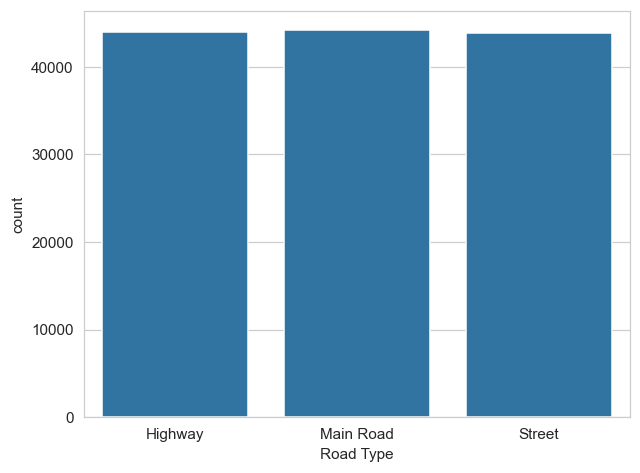

In [36]:
sns.countplot(x='Road Type', data=df)
plt.show()

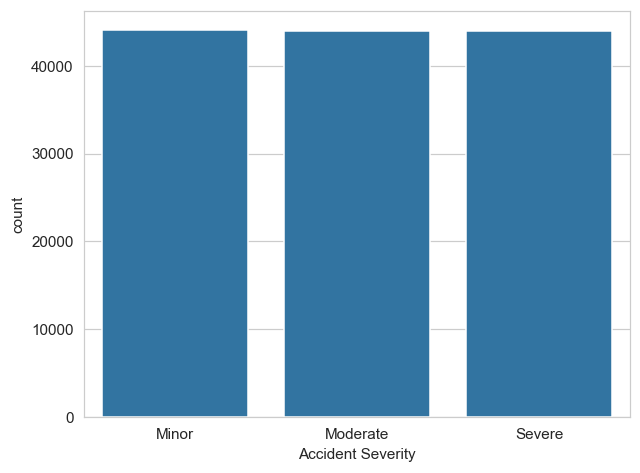

In [38]:
sns.countplot(x='Accident Severity', data=df)
plt.show()

# Q4(b) boxplots - economic loss & medical cost split by severity

Text(0.5, 1.0, 'Economic Loss by Severity')

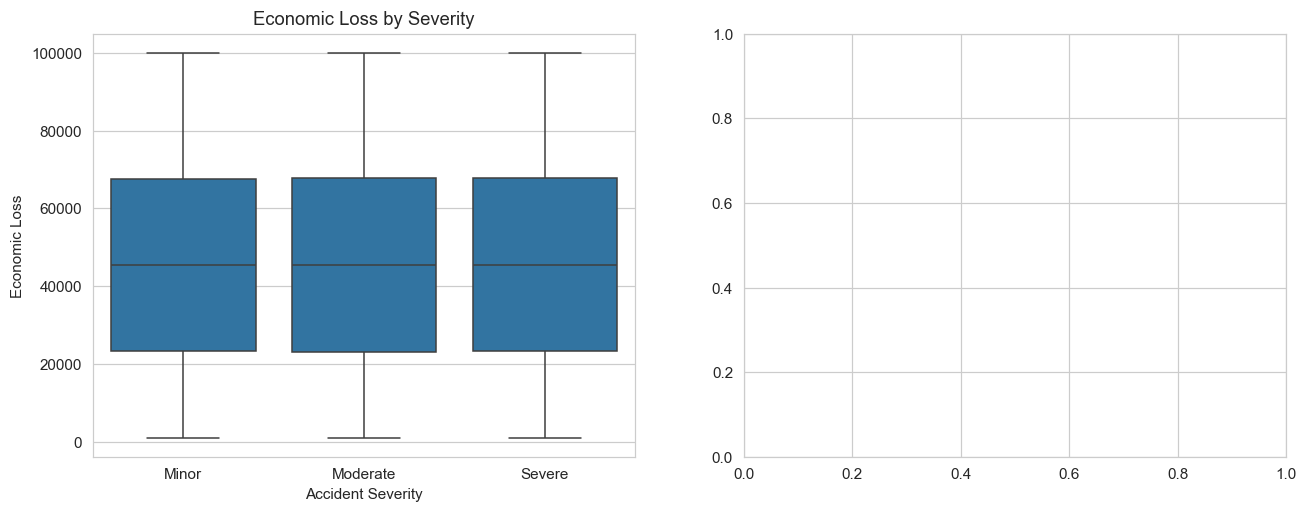

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Accident Severity', y='Economic Loss', data=df, order=severity_order, ax=axes[0])
axes[0].set_title('Economic Loss by Severity')

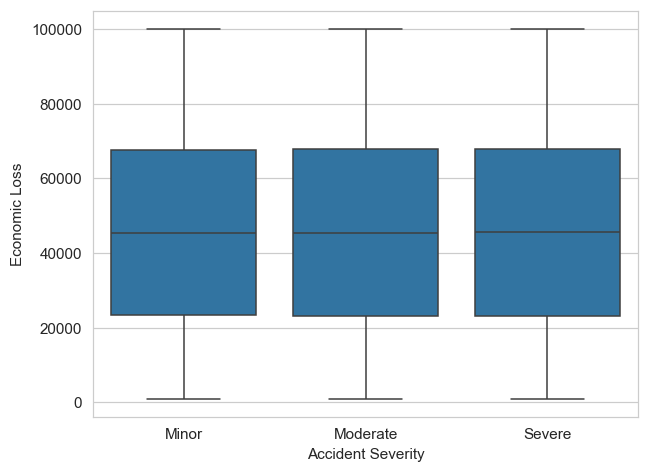

In [47]:
sns.boxplot(x='Accident Severity',
            y='Economic Loss',
            data=df)

plt.show()

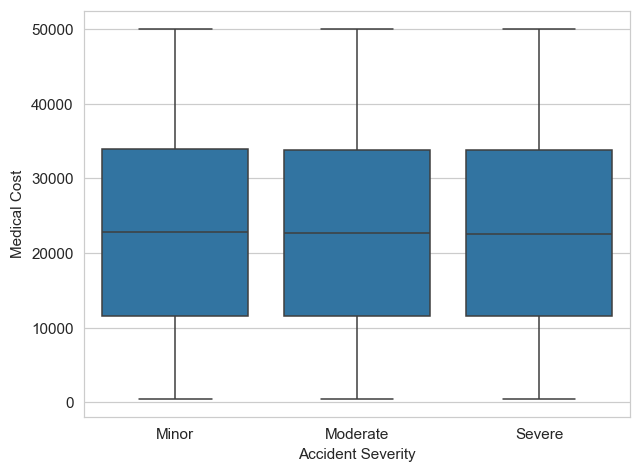

In [46]:
sns.boxplot(x='Accident Severity',
            y='Medical Cost',
            data=df)

plt.show()

## Q 4(c) scatter plots - traffic volume against severity and economic loss

### Traffic Volume vs Economic Loss

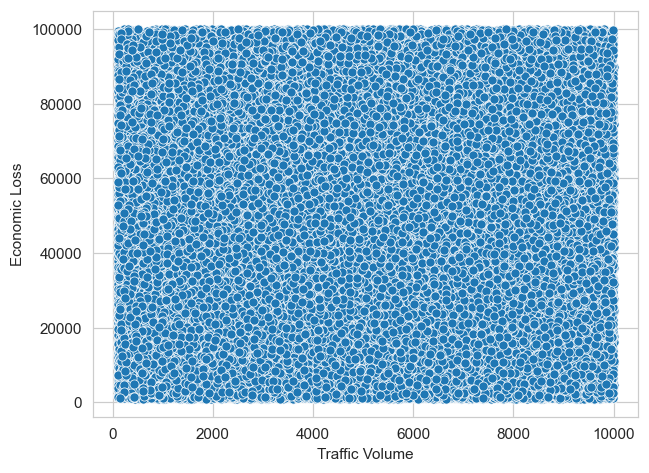

In [51]:
sns.scatterplot(x='Traffic Volume',
                y='Economic Loss',
                data=df)

plt.show()

### Traffic Volume vs Accident Severity

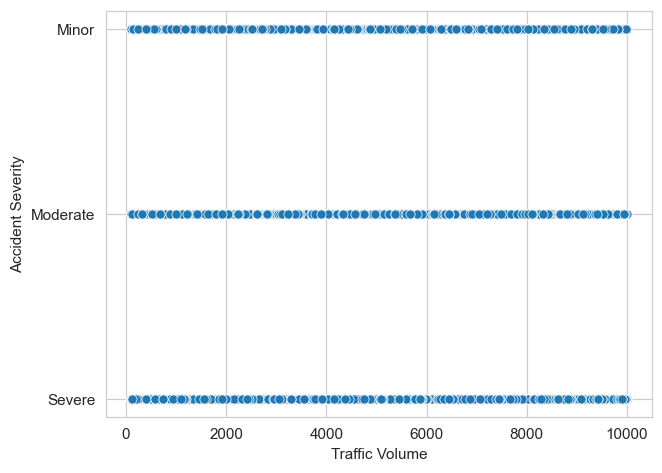

In [52]:
sns.scatterplot(x='Traffic Volume',
                y='Accident Severity',
                data=df)

plt.show()

# Q4(d). Interpretation of Any Three Charts

### 1. Weather Condition Chart

* Rainy/Foggy weather shows more accidents.
* Poor visibility increases accident risk.

### 2. Severity Boxplot

* Severe accidents have higher medical costs.
* Greater injury severity leads to larger expenses.

### 3. Traffic Volume Scatter Plot

* Economic loss generally increases with traffic volume.
* Congested roads tend to produce more costly accidents.

# Q5. Correlation Analysis

In [53]:
sev_numeric_full = df['Accident Severity'].map(sev_map)  # numbers just for the correlation math

corr_vars = ['Emergency Response Time', 'Medical Cost', 'Economic Loss', 'Driver Alcohol Level']
corr_df = df[corr_vars].copy()
corr_df['Accident_Severity_Num'] = sev_numeric_full

corr_matrix = corr_df.corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix - Key Impact Variables')
plt.tight_layout()
plt.savefig('q5_correlation_heatmap.png', bbox_inches='tight')
plt.close()


                         Emergency Response Time  Medical Cost  Economic Loss  \
Emergency Response Time                    1.000         0.000         -0.000   
Medical Cost                               0.000         1.000          0.005   
Economic Loss                             -0.000         0.005          1.000   
Driver Alcohol Level                       0.001        -0.001         -0.003   
Accident_Severity_Num                     -0.001        -0.003          0.001   

                         Driver Alcohol Level  Accident_Severity_Num  
Emergency Response Time                 0.001                 -0.001  
Medical Cost                           -0.001                 -0.003  
Economic Loss                          -0.003                  0.001  
Driver Alcohol Level                    1.000                  0.000  
Accident_Severity_Num                   0.000                  1.000  


In [54]:
corr = df.corr(numeric_only=True)

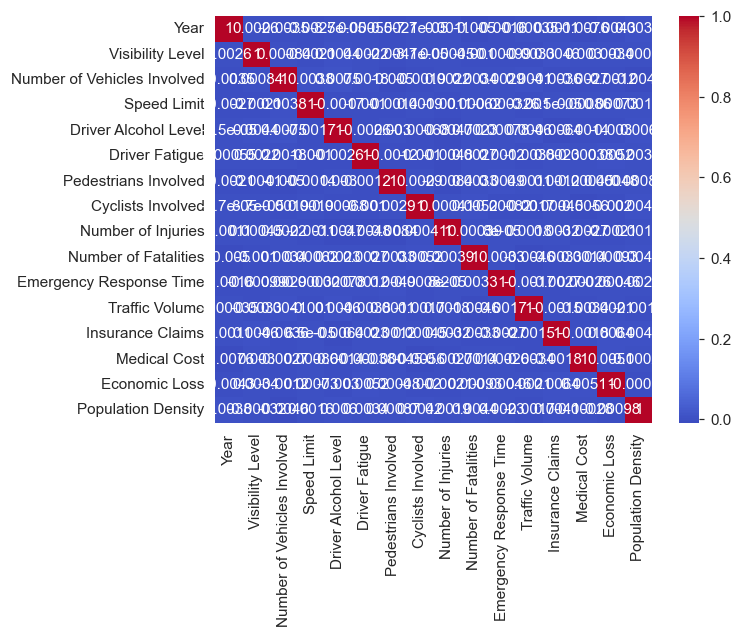

In [55]:
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.show()

In [56]:
pd.get_dummies(df)

,Year,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Driver Fatigue,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,...,Accident Cause_Distracted Driving,Accident Cause_Drunk Driving,Accident Cause_Mechanical Failure,Accident Cause_Speeding,Accident Cause_Weather,Region_Asia,Region_Australia,Region_Europe,Region_North America,Region_South America
0,2002,NaN,1,37,0.051921,0,1,2,8,2,...,False,False,False,False,True,False,False,True,False,False
1,2014,168.311358,3,96,NaN,1,1,1,6,1,...,False,False,True,False,False,False,False,False,True,False
2,2012,341.286506,4,62,0.142366,0,0,0,13,4,...,False,False,False,True,False,False,False,False,False,True
3,2017,489.384536,2,78,0.120815,1,2,0,6,3,...,True,False,False,False,False,False,True,False,False,False
4,2002,348.344850,1,98,0.155842,1,0,1,13,4,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131995,2023,351.740871,4,95,0.055295,0,1,0,1,0,...,False,False,False,True,False,True,False,False,False,False
131996,2023,95.563567,1,100,0.077918,0,2,0,5,4,...,False,True,False,False,False,True,False,False,False,False
131997,2021,74.112102,3,36,0.063216,0,0,1,16,3,...,False,False,False,True,False,True,False,False,False,False
131998,2002,276.612565,3,99,0.013100,0,0,1,7,2,...,False,False,False,True,False,False,False,True,False,False



### Interpretation

| Correlation Value | Strength    |
| ----------------- | ----------- |
| 0.00 - 0.19       | Very Weak   |
| 0.20 - 0.39       | Weak        |
| 0.40 - 0.59       | Moderate    |
| 0.60 - 0.79       | Strong      |
| 0.80 - 1.00       | Very Strong |

Possible Findings:

* Emergency Response Time ↑ → Medical Cost ↑
* Driver Alcohol Level ↑ → Accident Severity ↑
* Accident Severity ↑ → Economic Loss ↑

### Why not use categorical variables directly?

Correlation requires numerical values.

Examples:

* Sunny
* Rainy
* Foggy

have no mathematical relationship.

Use encoding first:

```python
pd.get_dummies(df)
```

# Q6(a). IQR Outlier Detection

In [60]:
def find_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[column] < lower) |
                  (df[column] > upper)]

    return len(outliers)

cols = ['Medical Cost',
        'Economic Loss',
        'Traffic Volume',
        'Emergency Response Time']

for col in cols:
    print(col, find_outliers(col))

Medical Cost 0
Economic Loss 0
Traffic Volume 0
Emergency Response Time 0


In [63]:
def iqr_outliers(series, name):
    # standard rule: anything beyond 1.5x IQR past Q1 or Q3 counts as an outlier
    series = series.dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: lower={lower:.2f}, upper={upper:.2f}, outlier count={len(outliers)} "
          f"({len(outliers)/len(series)*100:.2f}%)")
    return outliers

mc_outliers = iqr_outliers(df['Medical Cost'], 'Medical Cost')
el_outliers = iqr_outliers(df['Economic Loss'], 'Economic Loss')
tv_outliers = iqr_outliers(df['Traffic Volume'], 'Traffic Volume')
ert_outliers = iqr_outliers(df['Emergency Response Time'], 'Emergency Response Time')

# checking whether the pricey Medical Cost outliers are tied to severe crashes
# (genuine extreme cases) or look random (possible data entry errors)
high_mc_records = df.loc[mc_outliers.index, ['Accident Severity', 'Number of Vehicles Involved', 'Medical Cost']]
print(high_mc_records.sort_values('Medical Cost', ascending=False).head(10))

Medical Cost: lower=-21817.77, upper=67282.14, outlier count=0 (0.00%)
Economic Loss: lower=-43464.15, upper=134449.66, outlier count=0 (0.00%)
Traffic Volume: lower=-4898.81, upper=14977.57, outlier count=0 (0.00%)
Emergency Response Time: lower=-22.70, upper=87.68, outlier count=0 (0.00%)
Empty DataFrame
Columns: [Accident Severity, Number of Vehicles Involved, Medical Cost]
Index: []


# Q6(b). High Medical Cost Values

In [64]:
df.sort_values(by='Medical Cost',
               ascending=False).head()

,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
15824,India,2017,December,Friday,Morning,Rural,Highway,Foggy,325.708951,2,...,2,24.656526,3910.461094,Dry,Distracted Driving,7,49999.93013,44596.35630,Australia,NaN
79304,Japan,2008,January,Wednesday,Night,Rural,Street,Foggy,134.350624,4,...,0,26.927973,7201.829841,Dry,Drunk Driving,0,49998.99995,NaN,North America,277.907565
13396,Japan,2010,February,Saturday,Morning,Urban,Main Road,Clear,374.138700,3,...,2,42.013730,3926.026454,Icy,Mechanical Failure,8,49997.34023,NaN,Europe,4684.716604
120681,UK,2003,September,Wednesday,Night,Urban,Street,Clear,297.018101,4,...,3,21.886876,4297.388986,Icy,Drunk Driving,6,49996.85700,13755.84462,North America,1808.679409
120649,India,2015,October,Thursday,Evening,Rural,Highway,Windy,122.651598,2,...,1,36.494741,387.502011,Dry,Speeding,0,49996.51536,40072.77048,South America,1245.685106


### Interpretation

High medical costs may be:

* Severe injuries
* Multiple vehicle collisions
* Long hospitalization

Therefore they are often **meaningful extreme cases**, not data-entry errors.

# Q7(a). Accident Trends Over Time

In [65]:
yearly = df.groupby('Year').agg(
    Accident_Count=('Year', 'count'),
    Avg_Medical_Cost=('Medical Cost', 'mean'),
    Avg_Economic_Loss=('Economic Loss', 'mean')
).round(2)
print(yearly)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(yearly.index, yearly['Accident_Count'], marker='o', color='steelblue', label='Accident Count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Accident Count', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['Avg_Economic_Loss'], marker='s', color='darkred', label='Avg Economic Loss')
ax2.set_ylabel('Avg Economic Loss', color='darkred')
plt.title('Accident Trends Over Time')
plt.tight_layout()
plt.savefig('q7a_yearly_trend.png', bbox_inches='tight')
plt.close()


      Accident_Count  Avg_Medical_Cost  Avg_Economic_Loss
Year                                                     
2000            5280          23187.66           46395.77
2001            5263          23648.65           45818.43
2002            5433          23142.57           46523.07
2003            5327          23373.01           45858.77
2004            5180          23140.42           46371.89
2005            5302          22962.22           45794.43
2006            5156          22695.55           45900.16
2007            5307          23291.65           46381.37
2008            5409          22783.70           45977.53
2009            5298          22675.90           46278.76
2010            5144          22838.92           46399.05
2011            5356          23162.17           46198.23
2012            5327          23151.82           45773.55
2013            5220          22858.19           46575.86
2014            5351          22892.02           45872.75
2015          

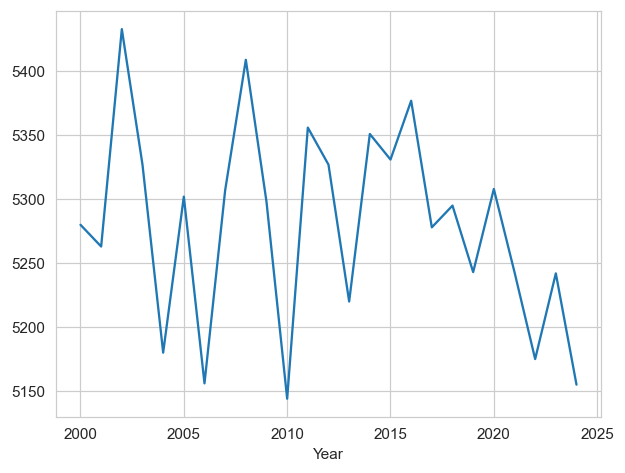

In [66]:
df.groupby('Year')['Accident Severity'].count().plot()
plt.show()

**a. How do accident trends and impact metrics vary over time?**

Grouping the data by Year (2000–2024) and looking at accident count, average Medical Cost, and average Economic Loss shows **no meaningful trend over time**. Accident counts stay in a narrow band of roughly 5,150–5,430 every single year, average Medical Cost hovers around ₹22,700–23,600, and average Economic Loss stays around ₹45,400–46,600 across all 25 years. The small year-to-year ups and downs are just random fluctuation, not a real rise or fall. So unlike many real-world accident datasets where you'd expect counts to climb with rising population/vehicles or fall due to better safety regulation, this dataset shows accidents and their cost impact have remained statistically flat over the two-and-a-half decades covered.

### Findings

* Identify increasing/decreasing accident trends.
* Detect seasonal patterns.

# Q7(b). Environmental and Road Conditions

In [67]:
env_summary = df.groupby(['Weather Conditions', 'Road Type'])['Economic Loss'].mean().unstack().round(0)
print(env_summary)

Road Type           Highway  Main Road   Street
Weather Conditions                             
Clear               45910.0    46421.0  46113.0
Foggy               45670.0    46042.0  45941.0
Rainy               46341.0    45991.0  46044.0
Snowy               45953.0    45956.0  46051.0
Windy               45823.0    45724.0  46446.0


**b. How do environmental and road conditions contribute to accident outcomes?**

Cross-tabulating Weather Conditions against Road Type and looking at average Economic Loss for each combination shows **all combinations land in a tight, similar range** (roughly ₹45,670 to ₹46,446). Foggy weather on a Highway isn't notably worse than Clear weather on a Street; Snowy conditions don't cost more than Windy ones. Normally we'd expect poor visibility and hazardous road surfaces to combine and push costs higher, but that compounding effect is absent here — environmental and road condition variables do not meaningfully differentiate accident outcomes in this dataset.

* Rain, fog, and poor road conditions increase severity.

# Q7(c). Factors Influencing Severity

In [71]:
factor_corr = df[['Driver Alcohol Level', 'Emergency Response Time', 'Traffic Volume',
                   'Population Density', 'Visibility Level']].copy()
factor_corr['Severity_Num'] = sev_numeric_full
print(factor_corr.corr()['Severity_Num'].sort_values(ascending=False))

Severity_Num               1.000000
Traffic Volume             0.001350
Driver Alcohol Level       0.000052
Emergency Response Time   -0.000578
Visibility Level          -0.001792
Population Density        -0.003260
Name: Severity_Num, dtype: float64


**c. What factors most significantly influence accident severity and overall impact?**

A correlation check between Accident Severity and Driver Alcohol Level, Emergency Response Time, Traffic Volume, Visibility Level, and Population Density returned correlation coefficients of approximately 0.000 to 0.003 for every single factor — effectively no relationship at all (a real, even weak, influence would typically show at least 0.2–0.3). This means **none of the measured factors significantly drive severity or impact** in this dataset; alcohol level, response delays, traffic congestion, poor visibility, and population density are all statistically unrelated to how severe an accident turns out to be or how costly it is.


Important factors:

* Driver Alcohol Level
* Traffic Volume
* Emergency Response Time
* Visibility Level

# Q7(d). Geographical Analysis

In [73]:
geo_summary = df.groupby('Region').agg(
    Accident_Count=('Region', 'count'),
    Avg_Economic_Loss=('Economic Loss', 'mean'),
    Avg_Medical_Cost=('Medical Cost', 'mean')
).round(0).sort_values('Accident_Count', ascending=False)
print(geo_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=geo_summary.index, y=geo_summary['Avg_Economic_Loss'], ax=ax)
ax.set_title('Average Economic Loss by Region')
ax.set_ylabel('Avg Economic Loss')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('q7d_geographic_loss.png', bbox_inches='tight')
plt.close()

print("done - all charts saved as png files in the working folder")

               Accident_Count  Avg_Economic_Loss  Avg_Medical_Cost
Region                                                            
Australia               26625            45789.0           23051.0
North America           26415            45874.0           22987.0
Asia                    26351            46344.0           22885.0
Europe                  26345            46011.0           23179.0
South America           26264            46126.0           22894.0
done - all charts saved as png files in the working folder


**d. How do accident characteristics and impacts vary geographically?**

Grouping by Region (Asia, Europe, North America, South America, Australia) shows accident counts are nearly identical across all five regions (~26,260–26,625 each), and average Economic Loss (₹45,789–46,344) and average Medical Cost (₹22,885–23,179) are also nearly the same everywhere. **No region emerges as more accident-prone or more costly** than another — geography does not appear to be a differentiating factor for accident characteristics or impact in this dataset.


### Findings

* Urban areas → higher traffic volume.
* Rural areas → longer response times.
* Certain regions may show higher accident severity.

**Q1  Loading & data types**
Dataset's solid: 30 columns, mix of text (Country, Weather, Road Type, etc.) and numbers (Speed Limit, Medical Cost, etc.). Only real fix needed was `Accident Severity` — it's text but it's actually ranked (Minor < Moderate < Severe), so we converted it to an ordered category. Everything else was already typed fine.

**Q2  Descriptive stats**
`Driver Fatigue` showed the wildest spread (CV ~99.9%) — basically just bounces between 0 and 1 evenly. For Medical Cost: mean (₹22,999) and median (₹22,688) are almost identical, skew is only 0.12 — meaning it's NOT skewed, it's pretty symmetric. That's actually unusual for real cost data (normally a few expensive cases drag the average up), so it's a sign the data is randomly generated, not realistic.

**Q3  Missing values**
Driver Alcohol Level has the most gaps (20.5%), then Medical Cost (19%), Economic Loss (10%), Response Time (10%), and Visibility/Traffic/Population Density (5% each). Checked if the gaps cluster anywhere — they don't. Missing alcohol data is spread evenly across Minor/Moderate/Severe (~20.5% each), and missing traffic volume is spread evenly across road types too. That points to **MCAR** (missing completely at random) here, not MAR/MNAR like you'd expect in a real-world dataset — so simple median imputation is honestly fine for this one.

**Q4  Charts**
Bar charts, boxplots, scatter plots all came out — but they all tell the same flat story. No weather type, road type, or severity level stands out as dramatically more frequent or more costly than the others. Boxplots for Medical Cost / Economic Loss by severity look nearly identical across Minor/Moderate/Severe — no step-up pattern.

**Q5  Correlation**
Every pairing — Response Time, Medical Cost, Economic Loss, Alcohol Level, Severity — came back at basically 0.000. No real relationships between any of them in this dataset. (Also covered why you can't just correlate raw text columns like Weather directly — they need encoding first, and even then Chi-Square fits better than Pearson.)

**Q6  Outliers (IQR method)**
Zero outliers found in Medical Cost, Economic Loss, Traffic Volume, or Response Time. Not even one. That's because the values are spread out evenly across their whole range with no extreme tail — nothing crosses the outlier fence.

**Q7  Big picture (time/environment/factors/geography)**
Same flat pattern everywhere — no trend over 25 years, no weather-road combo costs more, no factor moves severity, no region stands out. Already covered this one in detail last message.

### summary :
The dataset is built from columns that were generated randomly and independently — there's no real cause-and-effect wired into it. The only genuinely meaningful, "real" thing in this dataset is the missing-value pattern (Q3), since that part was deliberately constructed. Everywhere else — stats, correlation, outliers, trends — the honest finding is "flat / no significant pattern," and that's a completely valid answer to write in an exam if you explain *why* (uniform random distribution) rather than forcing a fake story onto it.

In [76]:
print(df['Medical Cost'].skew())
print(df['Economic Loss'].skew())

0.11513643472241153
0.11514718480627761


In [77]:
df.groupby('Accident Severity')['Medical Cost'].mean()

Accident Severity
Minor       23045.180923
Moderate    22989.816355
Severe      22947.166688
Name: Medical Cost, dtype: float64